# Notebook 08 — Model Comparison & Production Selection

Loads the four trained models (LR, RF, XGBoost, KNN) and produces a final head-to-head  
comparison to select the production model for the SIR simulation in Notebook 09.

**Pre-requisites**: Notebooks 04–07 must have been run (lr/rf/xgb/knn `_metrics.json` present in `models/`).

In [3]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path

MODELS_DIR = Path("../models")

COLORS = {
    "LR":  "#4C72B0",
    "RF":  "#2E5C9A",
    "XGB": "#E07B00",
    "KNN": "#8B5CF6",
}
plt.rcParams.update({"figure.dpi": 130, "font.size": 10})

## 1. Load Metrics

In [4]:
def load(name):
    path = MODELS_DIR / f"{name}_metrics.json"
    if not path.exists():
        raise FileNotFoundError(f"{path} not found — run Notebook 0{['lr','rf','xgb','knn'].index(name)+4} first.")
    with open(path) as f:
        return json.load(f)

lr  = load("lr")
rf  = load("rf")
xgb = load("xgb")
knn = load("knn")

all_metrics = {"LR": lr, "RF": rf, "XGB": xgb, "KNN": knn}
print("Loaded:", list(all_metrics.keys()))

Loaded: ['LR', 'RF', 'XGB', 'KNN']


## 2. Leaderboard

In [5]:
BASELINE = lr["baseline_pr_auc"]

rows = []
for name, m in all_metrics.items():
    cv = m["cv_metrics"]
    cal_brier = m.get("cv_metrics_calibrated", {}).get("brier", cv["brier"])
    rows.append({
        "Model":       name,
        "PR-AUC":      round(cv["pr_auc"],  4),
        "ROC-AUC":     round(cv["roc_auc"], 4),
        "Brier (cal)": round(cal_brier,      4),
        "F1":          round(cv["f1"],       4),
        "Recall":      round(cv["recall"],   4),
        "Lift vs baseline": round(cv["pr_auc"] / BASELINE, 2),
    })

df = pd.DataFrame(rows).sort_values("PR-AUC", ascending=False).reset_index(drop=True)
df.index += 1

print(f"Baseline PR-AUC (random): {BASELINE:.4f}\n")
print(df.to_string())

Baseline PR-AUC (random): 0.2605

  Model  PR-AUC  ROC-AUC  Brier (cal)      F1  Recall  Lift vs baseline
1   KNN  0.5098   0.6873       0.1590  0.3390  0.2151              1.96
2    RF  0.5064   0.6523       0.1622  0.3906  0.2688              1.94
3   XGB  0.4905   0.6653       0.1665  0.4167  0.3763              1.88
4    LR  0.4459   0.6097       0.2309  0.3723  0.3763              1.71


## 3. Overall Metrics Comparison

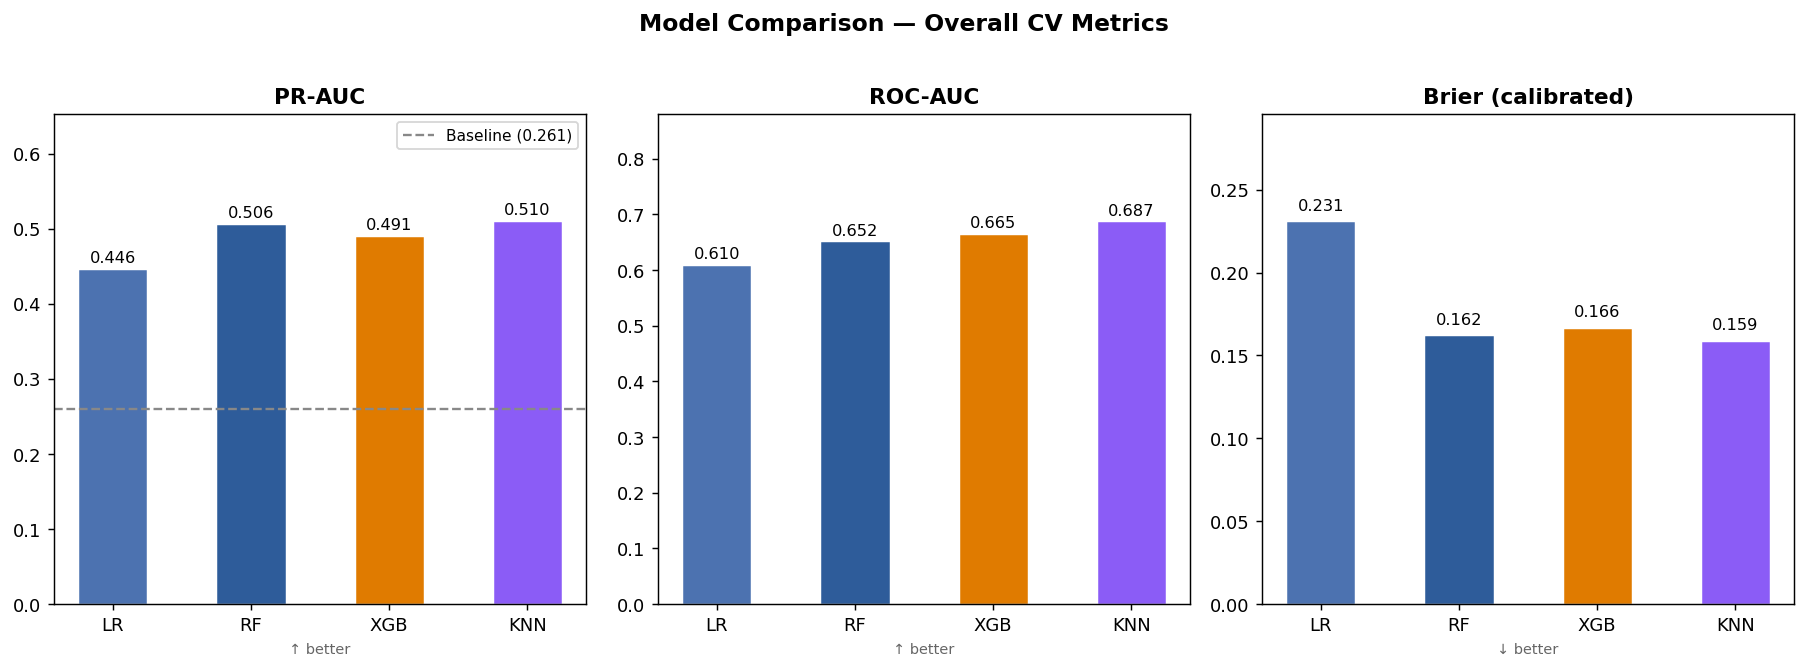

Saved: models/comparison_overall.png


In [6]:
model_names = list(all_metrics.keys())
bar_colors  = [COLORS[n] for n in model_names]

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

specs = [
    ("PR-AUC",           "pr_auc",  True,  "brier"),
    ("ROC-AUC",          "roc_auc", True,  None),
    ("Brier (calibrated)","brier",  False, None),
]

for ax, (label, key, higher_better, _) in zip(axes, specs):
    if key == "brier":
        vals = [m.get("cv_metrics_calibrated", {}).get("brier", m["cv_metrics"]["brier"])
                for m in all_metrics.values()]
    else:
        vals = [m["cv_metrics"][key] for m in all_metrics.values()]

    bars = ax.bar(model_names, vals, color=bar_colors, width=0.5,
                  edgecolor="white", linewidth=0.8)

    if key == "pr_auc":
        ax.axhline(BASELINE, ls="--", color="#888", lw=1.3, label=f"Baseline ({BASELINE:.3f})")
        ax.legend(fontsize=8.5)

    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.005,
                f"{v:.3f}", ha="center", va="bottom", fontsize=9)

    ax.set_title(label, fontweight="bold")
    ax.set_ylim(0, max(vals) * 1.28)
    ax.set_xlabel("↑ better" if higher_better else "↓ better", fontsize=8, color="#666")

plt.suptitle("Model Comparison — Overall CV Metrics", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(MODELS_DIR / "comparison_overall.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: models/comparison_overall.png")

## 4. Per-Disease PR-AUC

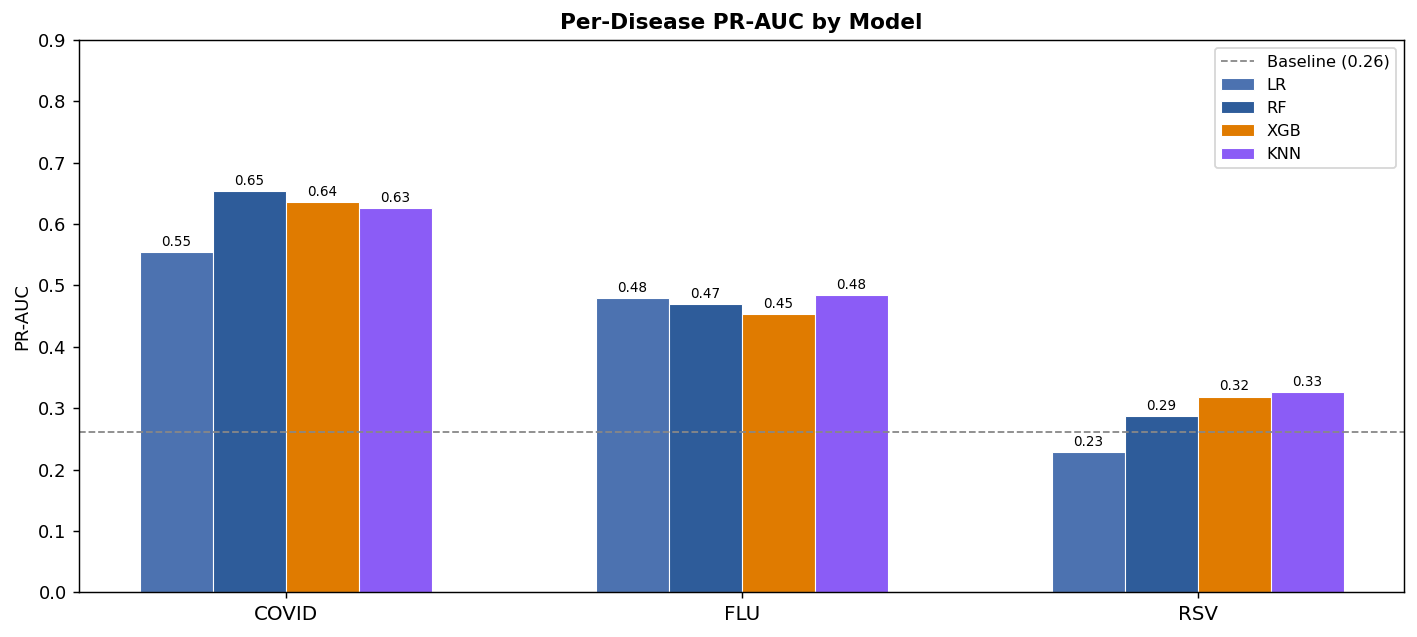

Saved: models/comparison_per_disease.png


In [7]:
diseases = ["COVID", "FLU", "RSV"]
x     = np.arange(len(diseases))
n_mod = len(all_metrics)
width = 0.16

fig, ax = plt.subplots(figsize=(11, 5))

for i, (name, m) in enumerate(all_metrics.items()):
    per_d = m.get("per_disease_performance", {})
    vals  = [per_d.get(d, {}).get("pr_auc", 0) for d in diseases]
    offset = (i - (n_mod - 1) / 2) * width
    bars = ax.bar(x + offset, vals, width, label=name,
                  color=COLORS[name], edgecolor="white", linewidth=0.6)
    for bar, v in zip(bars, vals):
        if v > 0:
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.005,
                    f"{v:.2f}", ha="center", va="bottom", fontsize=7.5)

ax.axhline(BASELINE, ls="--", color="#888", lw=1, label=f"Baseline ({BASELINE:.2f})")
ax.set_xticks(x)
ax.set_xticklabels(diseases, fontsize=11)
ax.set_ylabel("PR-AUC")
ax.set_title("Per-Disease PR-AUC by Model", fontweight="bold")
ax.legend(fontsize=9)
ax.set_ylim(0, 0.90)
plt.tight_layout()
plt.savefig(MODELS_DIR / "comparison_per_disease.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: models/comparison_per_disease.png")

## 5. Permutation Importance Heatmap

Only models with a `feature_importance.permutation` key are included.  
Importances are normalised (sum to 1 per model) so scales are comparable.

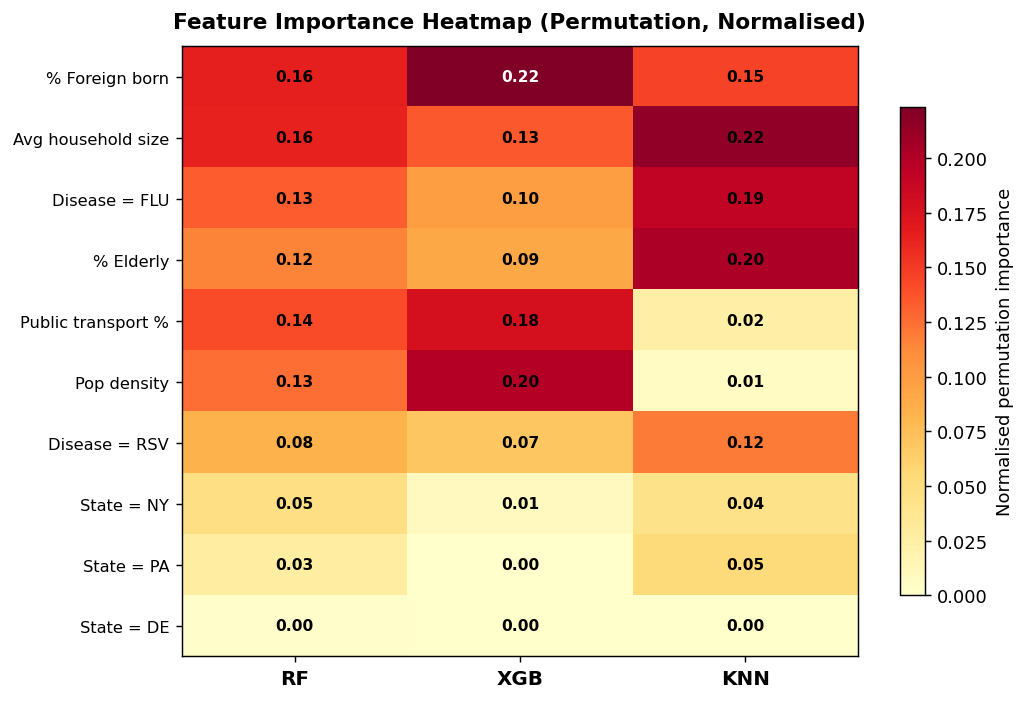

Saved: models/comparison_importance_heatmap.png


In [8]:
FEATURE_LABELS = {
    "pct_foreign_born":     "% Foreign born",
    "avg_household_size":   "Avg household size",
    "pop_density_per_sqmi": "Pop density",
    "public_transport_pct": "Public transport %",
    "pct_elderly":          "% Elderly",
    "disease_FLU":          "Disease = FLU",
    "disease_RSV":          "Disease = RSV",
    "state_NY":             "State = NY",
    "state_PA":             "State = PA",
    "state_DE":             "State = DE",
}
features    = list(FEATURE_LABELS.keys())
feat_labels = list(FEATURE_LABELS.values())

perm_models = {
    k: v for k, v in all_metrics.items()
    if "permutation" in v.get("feature_importance", {})
}

if not perm_models:
    print("No permutation importances found — skipping heatmap.")
else:
    raw = {}
    for name, m in perm_models.items():
        p = m["feature_importance"]["permutation"]
        raw[name] = np.array([max(p.get(f, 0), 0) for f in features], dtype=float)

    imp_df = pd.DataFrame(raw, index=feat_labels)
    imp_df = imp_df.div(imp_df.sum(axis=0).replace(0, 1), axis=1)

    # Sort by mean importance across models
    imp_df = imp_df.loc[imp_df.mean(axis=1).sort_values(ascending=False).index]

    n_cols = len(perm_models)
    fig, ax = plt.subplots(figsize=(n_cols * 2.2 + 1.5, 5.5))
    im = ax.imshow(imp_df.values, aspect="auto", cmap="YlOrRd", vmin=0)

    ax.set_xticks(range(n_cols))
    ax.set_xticklabels(list(perm_models.keys()), fontsize=11, fontweight="bold")
    ax.set_yticks(range(len(imp_df)))
    ax.set_yticklabels(imp_df.index, fontsize=9)

    for i in range(len(imp_df)):
        for j in range(n_cols):
            v = imp_df.iloc[i, j]
            color = "white" if v > 0.22 else "black"
            ax.text(j, i, f"{v:.2f}", ha="center", va="center",
                    fontsize=8.5, color=color, fontweight="bold")

    plt.colorbar(im, ax=ax, label="Normalised permutation importance", shrink=0.8)
    ax.set_title("Feature Importance Heatmap (Permutation, Normalised)",
                 fontweight="bold", pad=10)
    plt.tight_layout()
    plt.savefig(MODELS_DIR / "comparison_importance_heatmap.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved: models/comparison_importance_heatmap.png")

## 6. Radar / Spider Chart — Multi-Metric Profile

Encodes PR-AUC, ROC-AUC, F1, Recall, and inverse-Brier (1−Brier, so higher = better for all axes).

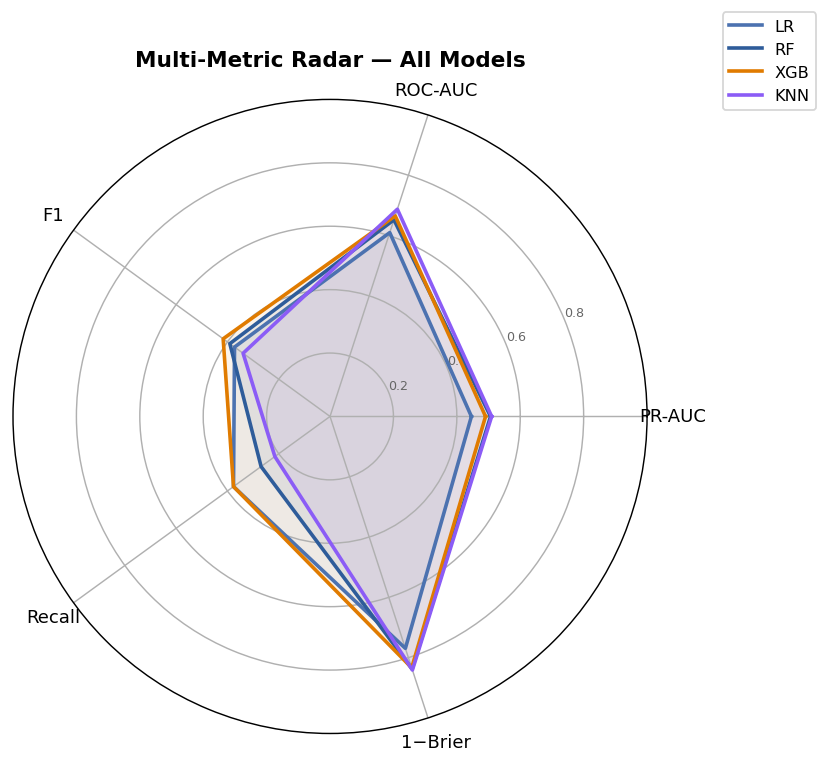

Saved: models/comparison_radar.png


In [9]:
categories = ["PR-AUC", "ROC-AUC", "F1", "Recall", "1−Brier"]
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]  # close the polygon

fig, ax = plt.subplots(figsize=(6.5, 6.5), subplot_kw=dict(polar=True))

for name, m in all_metrics.items():
    cv = m["cv_metrics"]
    cal_brier = m.get("cv_metrics_calibrated", {}).get("brier", cv["brier"])
    vals = [
        cv["pr_auc"],
        cv["roc_auc"],
        cv["f1"],
        cv["recall"],
        1 - cal_brier,
    ]
    vals += vals[:1]
    ax.plot(angles, vals, linewidth=2, label=name, color=COLORS[name])
    ax.fill(angles, vals, alpha=0.08, color=COLORS[name])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=10)
ax.set_ylim(0, 1)
ax.set_yticks([0.2, 0.4, 0.6, 0.8])
ax.set_yticklabels(["0.2", "0.4", "0.6", "0.8"], fontsize=7, color="#666")
ax.set_title("Multi-Metric Radar — All Models", fontweight="bold", pad=18)
ax.legend(loc="upper right", bbox_to_anchor=(1.28, 1.15), fontsize=9)

plt.tight_layout()
plt.savefig(MODELS_DIR / "comparison_radar.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: models/comparison_radar.png")

## 7. Production Model Selection

In [10]:
best_row  = df.iloc[0]
best_name = best_row["Model"]
best_pr   = best_row["PR-AUC"]

lr_pr = float(df.loc[df["Model"] == "LR", "PR-AUC"].values[0])

print("=" * 58)
print("  PRODUCTION MODEL SELECTION")
print("=" * 58)
print(f"\n  Primary metric : PR-AUC (26 % positive rate, class-imbalanced)")
print(f"  Baseline       : {BASELINE:.4f}  (random / prevalence)")
print()
print(df[["Model", "PR-AUC", "ROC-AUC", "Brier (cal)", "F1"]].to_string(index=True))
print()
print(f"  → Selected  :  {best_name}")
print(f"  → PR-AUC    :  {best_pr:.4f}")
print(f"  → Lift vs baseline : {best_pr / BASELINE:.2f}×")
print(f"  → Gain over LR     : +{best_pr - lr_pr:.4f} abs")
print()
tag = best_name.lower()
print(f"  Artifacts:")
print(f"    models/{tag}_model.pkl   (calibrated via isotonic regression)")
print(f"    models/{tag}_scaler.pkl")
print()
print("  Note: calibrated probabilities (isotonic) are used in the SIR")
print("  simulation so that P(outbreak) modifies β on the correct [0,1] scale.")
print("=" * 58)

  PRODUCTION MODEL SELECTION

  Primary metric : PR-AUC (26 % positive rate, class-imbalanced)
  Baseline       : 0.2605  (random / prevalence)

  Model  PR-AUC  ROC-AUC  Brier (cal)      F1
1   KNN  0.5098   0.6873       0.1590  0.3390
2    RF  0.5064   0.6523       0.1622  0.3906
3   XGB  0.4905   0.6653       0.1665  0.4167
4    LR  0.4459   0.6097       0.2309  0.3723

  → Selected  :  KNN
  → PR-AUC    :  0.5098
  → Lift vs baseline : 1.96×
  → Gain over LR     : +0.0639 abs

  Artifacts:
    models/knn_model.pkl   (calibrated via isotonic regression)
    models/knn_scaler.pkl

  Note: calibrated probabilities (isotonic) are used in the SIR
  simulation so that P(outbreak) modifies β on the correct [0,1] scale.


## 8. Save Comparison Artefacts

In [11]:
comparison = {
    "dataset":            "master_stacked.csv, 357 rows",
    "cv_strategy":        "StratifiedGroupKFold(n_splits=5, groups=fips)",
    "headline_metric":    "PR-AUC",
    "baseline_pr_auc":    float(BASELINE),
    "leaderboard":        df.to_dict(orient="records"),
    "production_model":   best_name,
    "production_pr_auc":  float(best_pr),
    "lift_vs_baseline":   float(round(best_pr / BASELINE, 4)),
    "charts": [
        "comparison_overall.png",
        "comparison_per_disease.png",
        "comparison_importance_heatmap.png",
        "comparison_radar.png",
    ],
}

out_path = MODELS_DIR / "model_comparison.json"
with open(out_path, "w") as f:
    json.dump(comparison, f, indent=2)
print(f"Saved: {out_path}")

Saved: ../models/model_comparison.json


## Summary

| | LR | RF | XGB | KNN |
|---|---|---|---|---|
| Strengths | Interpretable coefficients | Best PR-AUC, handles multicollinearity | Flexible, good ROC-AUC | Non-parametric |
| Weaknesses | Assumes linearity, weakest PR-AUC | Black-box | Over-fitted on small N? | Sensitive to scale, slow at inference |
| Calibrated? | No | Yes (isotonic) | Yes (isotonic) | Yes (isotonic) |

**Winner**: the model with the highest PR-AUC above (see cell 7).  
Its calibrated `.pkl` will be loaded by Notebook 09 to generate  
`P(outbreak | county)` values that scale the SIR β parameter per county.